In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv("weatherHistory.csv")

In [3]:
df.head() 
#precip type, yağış türü
#apparent temperature, hissedilen
#humidity, nem

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [4]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [6]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [7]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [8]:
df[df.isnull().any(axis=1)]

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
52672,2012-04-11 16:00:00.000 +0200,Mostly Cloudy,NaN,19.016667,19.016667,0.26,14.8764,163.0,9.982,0.0,1002.40,Mostly cloudy until night.
52674,2012-04-11 18:00:00.000 +0200,Mostly Cloudy,NaN,17.850000,17.850000,0.28,13.7977,169.0,9.982,0.0,1001.79,Mostly cloudy until night.
52675,2012-04-11 19:00:00.000 +0200,Mostly Cloudy,NaN,16.322222,16.322222,0.32,10.8192,151.0,9.982,0.0,1001.60,Mostly cloudy until night.
52677,2012-04-11 21:00:00.000 +0200,Mostly Cloudy,NaN,12.566667,12.566667,0.43,9.0160,159.0,9.982,0.0,1001.92,Mostly cloudy until night.
52678,2012-04-11 22:00:00.000 +0200,Mostly Cloudy,NaN,12.927778,12.927778,0.47,17.6295,197.0,16.100,0.0,1002.20,Mostly cloudy until night.
...,...,...,...,...,...,...,...,...,...,...,...,...
95584,2016-10-31 19:00:00.000 +0100,Mostly Cloudy,NaN,8.322222,7.044444,0.85,8.0339,290.0,0.000,0.0,1021.73,Mostly cloudy starting in the afternoon.
95585,2016-10-31 20:00:00.000 +0100,Mostly Cloudy,NaN,7.627778,6.183333,0.87,8.2271,293.0,0.000,0.0,1021.76,Mostly cloudy starting in the afternoon.
95586,2016-10-31 21:00:00.000 +0100,Mostly Cloudy,NaN,7.111111,5.511111,0.89,8.5008,297.0,0.000,0.0,1021.81,Mostly cloudy starting in the afternoon.
95587,2016-10-31 22:00:00.000 +0100,Partly Cloudy,NaN,6.672222,4.961111,0.90,8.6457,299.0,0.000,0.0,1021.83,Mostly cloudy starting in the afternoon.


In [9]:
df["Precip Type"].unique()

array(['rain', 'snow', nan], dtype=object)

In [10]:
df = df.dropna().reset_index(drop=True)

In [11]:
df = df.drop(columns="Daily Summary")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95936 entries, 0 to 95935
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            95936 non-null  object 
 1   Summary                   95936 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           95936 non-null  float64
 4   Apparent Temperature (C)  95936 non-null  float64
 5   Humidity                  95936 non-null  float64
 6   Wind Speed (km/h)         95936 non-null  float64
 7   Wind Bearing (degrees)    95936 non-null  float64
 8   Visibility (km)           95936 non-null  float64
 9   Loud Cover                95936 non-null  float64
 10  Pressure (millibars)      95936 non-null  float64
dtypes: float64(8), object(3)
memory usage: 8.1+ MB


In [13]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,95936.000000,95936.000000,95936.000000,95936.000000,95936.000000,95936.000000,95936.0,95936.000000
mean,11.940976,10.862531,0.734841,10.804936,187.518773,10.362402,0.0,1003.150038
std,9.570671,10.717812,0.195724,6.920727,107.385351,4.173780,0.0,117.276976
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.604167,2.276389,0.600000,5.796000,116.000000,8.372000,0.0,1011.890000
50%,12.033333,12.033333,0.780000,9.933700,180.000000,10.046400,0.0,1016.420000
75%,18.844444,18.844444,0.890000,14.135800,290.000000,14.812000,0.0,1021.050000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [14]:
df["Summary"].unique()

array(['Partly Cloudy', 'Mostly Cloudy', 'Overcast', 'Foggy',
       'Breezy and Mostly Cloudy', 'Clear', 'Breezy and Partly Cloudy',
       'Breezy and Overcast', 'Humid and Mostly Cloudy',
       'Humid and Partly Cloudy', 'Windy and Foggy', 'Windy and Overcast',
       'Breezy and Foggy', 'Windy and Partly Cloudy', 'Breezy',
       'Dry and Partly Cloudy', 'Windy and Mostly Cloudy',
       'Dangerously Windy and Partly Cloudy', 'Dry', 'Windy',
       'Humid and Overcast', 'Light Rain', 'Drizzle', 'Windy and Dry',
       'Dry and Mostly Cloudy', 'Breezy and Dry', 'Rain'], dtype=object)

In [15]:
df["Precip Type"].unique()

array(['rain', 'snow'], dtype=object)

In [16]:
df["Precip Type"].value_counts()

Precip Type
rain    85224
snow    10712
Name: count, dtype: int64

In [17]:
df["Precip Type"] = np.where(df["Precip Type"].str.contains("rain"), 0, 1)

In [18]:
df["Precip Type"].value_counts()

Precip Type
0    85224
1    10712
Name: count, dtype: int64

In [19]:
df["Formatted Date"].unique()

array(['2006-04-01 00:00:00.000 +0200', '2006-04-01 01:00:00.000 +0200',
       '2006-04-01 02:00:00.000 +0200', ...,
       '2016-09-09 21:00:00.000 +0200', '2016-09-09 22:00:00.000 +0200',
       '2016-09-09 23:00:00.000 +0200'], shape=(95912,), dtype=object)

In [20]:
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)

In [21]:
df["Day"] = df["Formatted Date"].dt.day
df["Month"] = df["Formatted Date"].dt.month
df["Year"] = df["Formatted Date"].dt.year

In [22]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Day,Month,Year
0,2006-03-31 22:00:00+00:00,Partly Cloudy,0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,31,3,2006
1,2006-03-31 23:00:00+00:00,Partly Cloudy,0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,31,3,2006
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,1,4,2006
3,2006-04-01 01:00:00+00:00,Partly Cloudy,0,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,1,4,2006
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,0,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,1,4,2006


In [23]:
df["Loud Cover"].unique()

array([0.])

In [24]:
df1 = df.drop(["Formatted Date","Summary","Loud Cover"], axis=1)

In [25]:
df2 = df1.drop(["Day","Month","Year"], axis=1)

In [26]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95936 entries, 0 to 95935
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Precip Type               95936 non-null  int64  
 1   Temperature (C)           95936 non-null  float64
 2   Apparent Temperature (C)  95936 non-null  float64
 3   Humidity                  95936 non-null  float64
 4   Wind Speed (km/h)         95936 non-null  float64
 5   Wind Bearing (degrees)    95936 non-null  float64
 6   Visibility (km)           95936 non-null  float64
 7   Pressure (millibars)      95936 non-null  float64
 8   Day                       95936 non-null  int32  
 9   Month                     95936 non-null  int32  
 10  Year                      95936 non-null  int32  
dtypes: float64(7), int32(3), int64(1)
memory usage: 7.0 MB


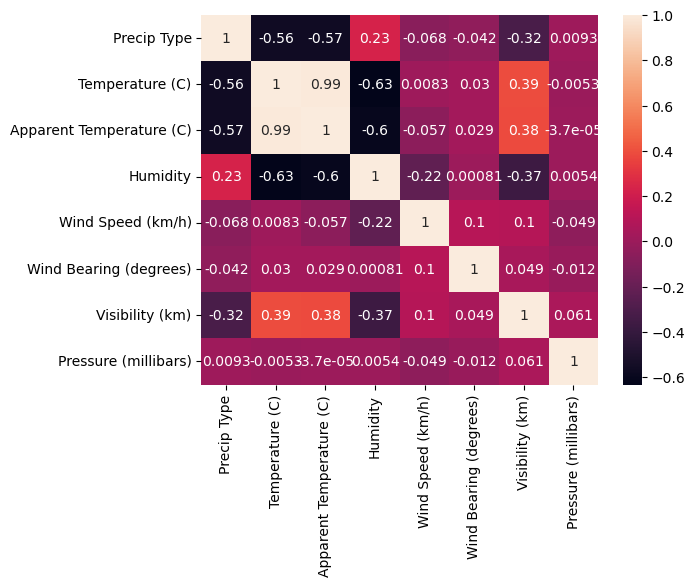

In [27]:
sns.heatmap(df2.corr(), annot=True)
plt.show()

In [28]:
# dependent and independent 
X = df2.drop("Humidity", axis=1)
y = df2["Humidity"]

In [29]:
# train - test split

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [32]:
X_train

,Precip Type,Temperature (C),Apparent Temperature (C),Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
41086,0,13.272222,13.272222,24.8101,176.0,11.5276,992.64
36100,0,15.138889,15.138889,3.3649,320.0,14.9086,1020.78
56649,0,27.450000,28.577778,13.0088,69.0,11.2700,1012.82
26069,0,10.022222,10.022222,10.5616,26.0,14.9569,1026.05
81767,1,-1.561111,-4.133333,6.8264,167.0,9.9015,1021.84
...,...,...,...,...,...,...,...
49015,0,1.933333,-1.072222,10.3523,142.0,3.5903,1023.49
68229,0,6.644444,5.605556,6.0697,278.0,5.8604,1005.70
8076,0,20.000000,20.000000,23.5382,338.0,11.2056,1020.95
52981,0,18.888889,18.888889,14.4900,150.0,9.9820,1016.50


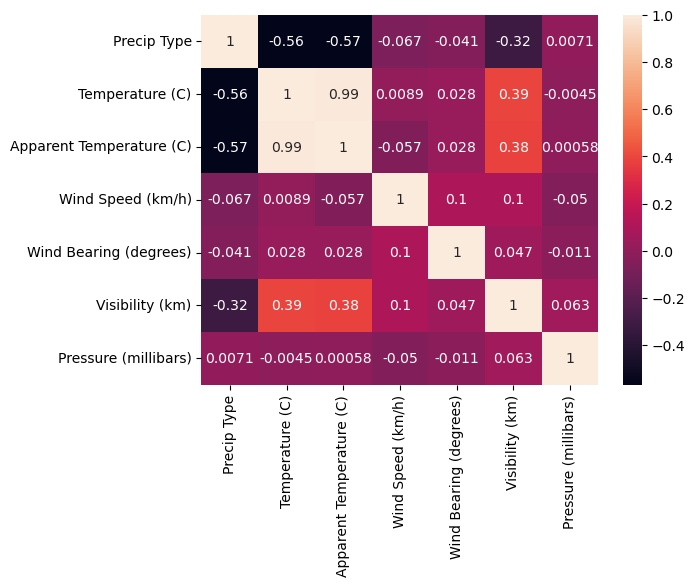

In [33]:
sns.heatmap(X_train.corr(), annot=True)
plt.show()

In [34]:
X_train.corr()

,Precip Type,Temperature (C),Apparent Temperature (C),Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
Precip Type,1.000000,-0.563830,-0.566568,-0.067305,-0.041397,-0.317305,0.007097
Temperature (C),-0.563830,1.000000,0.992638,0.008917,0.028488,0.393650,-0.004515
Apparent Temperature (C),-0.566568,0.992638,1.000000,-0.057002,0.027617,0.382835,0.000583
Wind Speed (km/h),-0.067305,0.008917,-0.057002,1.000000,0.102731,0.101429,-0.049602
Wind Bearing (degrees),-0.041397,0.028488,0.027617,0.102731,1.000000,0.047081,-0.011150
Visibility (km),-0.317305,0.393650,0.382835,0.101429,0.047081,1.000000,0.063119
Pressure (millibars),0.007097,-0.004515,0.000583,-0.049602,-0.011150,0.063119,1.000000


In [35]:
# Korelasyon oranları istenilenden yüksek olanları çıkarmaya yarayan fonksiyon;
def correlation_for_dropping(df, threshold):
    columns_to_drop = set()
    corr = df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j]) > threshold:
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop

In [36]:
columns_dropping = correlation_for_dropping(X_train, 0.85)

In [37]:
X_train.shape

(71952, 7)

In [38]:
X_train.drop(columns_dropping, axis=1, inplace=True)
X_test.drop(columns_dropping, axis=1, inplace=True)

In [39]:
X_train.shape

(71952, 6)

In [40]:
# Standard scaler

In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [42]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
linear =  LinearRegression()

Mean Squared Error: 0.019491447888967596
Mean Absoluted Error: 0.11028332545876371
r2 Score 0.49567228534670593


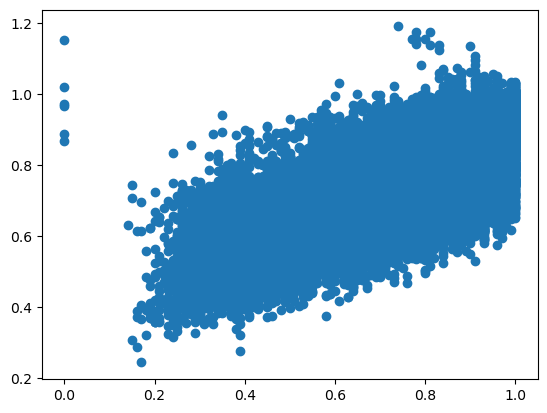

In [44]:
linear.fit(X_train, y_train)
y_pred = linear.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absoluted Error:", mae)
print("r2 Score", r2)
plt.scatter(y_test, y_pred)
plt.show()

In [48]:
from sklearn.linear_model import Lasso
lasso = Lasso()

Mean Squared Error: 0.038648550164656355
Mean Absoluted Error: 0.16386171064556343
r2 Score -4.4681255713108214e-06


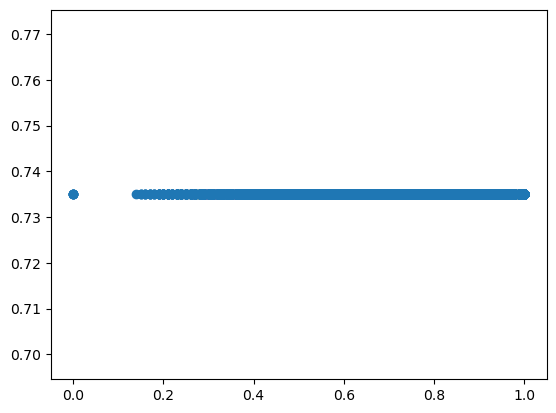

In [49]:
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absoluted Error:", mae)
print("r2 Score", r2)
plt.scatter(y_test, y_pred)
plt.show()

In [50]:
from sklearn.linear_model import Ridge
ridge = Ridge()

Mean Squared Error: 0.019491450686429882
Mean Absoluted Error: 0.11028339952827712
r2 Score 0.49567221296430675


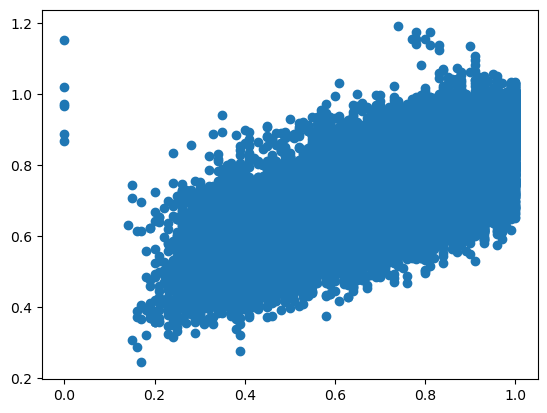

In [51]:
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absoluted Error:", mae)
print("r2 Score", r2)
plt.scatter(y_test, y_pred)
plt.show()

In [52]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet()

Mean Squared Error: 0.038648550164656355
Mean Absoluted Error: 0.16386171064556343
r2 Score -4.4681255713108214e-06


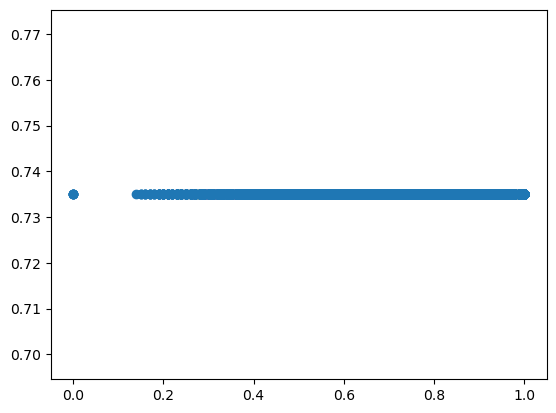

In [54]:
elastic.fit(X_train, y_train)
y_pred = elastic.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absoluted Error:", mae)
print("r2 Score", r2)
plt.scatter(y_test, y_pred)
plt.show()

In [55]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)

Lamba: 0.00012367394359875632
Mean Squared Error: 0.019492744044695705
Mean Absoluted Error: 0.11029254983196597
r2 Score 0.49563874821493836


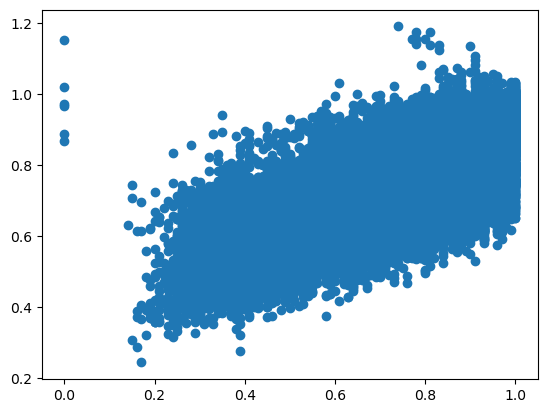

In [68]:
lassocv.fit(X_train, y_train)
y_pred = lassocv.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Lamba:", lassocv.alpha_)
print("Mean Squared Error:", mse)
print("Mean Absoluted Error:", mae)
print("r2 Score", r2)
plt.scatter(y_test, y_pred)
plt.show()

In [57]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)

Lamba: 10.0
Mean Squared Error: 0.019491476610622546
Mean Absoluted Error: 0.11028407152706715
r2 Score 0.4956715421937762


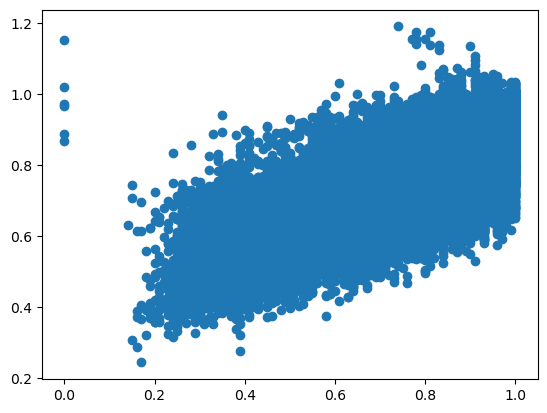

In [71]:
ridgecv.fit(X_train, y_train)
y_pred = ridgecv.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Lamba:", ridgecv.alpha_)
print("Mean Squared Error:", mse)
print("Mean Absoluted Error:", mae)
print("r2 Score", r2)
plt.scatter(y_test, y_pred)
plt.show()

In [59]:
from sklearn.linear_model import ElasticNetCV
elasticcv = ElasticNetCV(cv=5)

Lamba: 0.00024734788719751264
Mean Squared Error: 0.0194927835000591
Mean Absoluted Error: 0.11029324547724455
r2 Score 0.49563772733473666


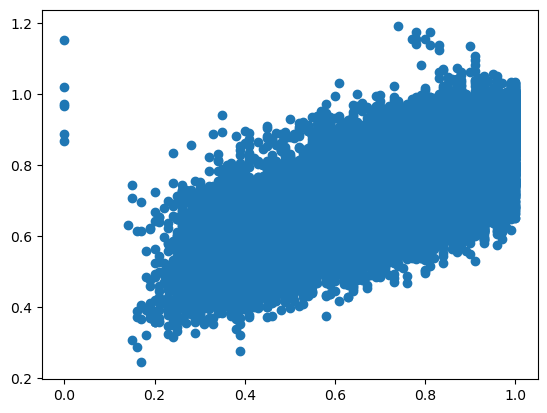

In [70]:
elasticcv.fit(X_train, y_train)
y_pred = elasticcv.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Lamba:", elasticcv.alpha_)
print("Mean Squared Error:", mse)
print("Mean Absoluted Error:", mae)
print("r2 Score", r2)
plt.scatter(y_test, y_pred)
plt.show()